In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

In [3]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

### Set confituration for all d_ij(BMF)

In [4]:
x = np.linspace(0, 45, 400)
mock_data = pd.DataFrame()
mock_data["position"] = x

In [5]:
meta_base = {
  "sample": "BMF_mock",
  "material": "BaMgF4",
  "method": "wedge",
  "wavelength_nm": 1064.0,
  "ref_ch": 1,
  "sig_ch": 2,
  "repetition": "1000Hz",
  "operator": "user",
  "notes": "",
  "start": 13.0,
  "end": 21.0,
  "step": 0.1,
  "timestamp": "2026-01-08T12:00:00.000000",
  "thickness_info": {
    "wedge_angle_deg": 0.2,
    "t_center_mm": 1.0
  },
  "beam_r_x": 359.6,
  "beam_r_y": 423.2
}

#### x cut

In [6]:
meta_d32 = copy.deepcopy(meta_base)
meta_d32["crystal_orientation"] = "100"
meta_d32["rot/trans_axis"] = "001"
meta_d32["input_polarization"] = 0.0
meta_d32["detected_polarization"] = 90.0

#### y cut

In [7]:
meta_d31 = copy.deepcopy(meta_base)
meta_d31["crystal_orientation"] = "010"
meta_d31["rot/trans_axis"] = "001"
meta_d31["input_polarization"] = 0.0
meta_d31["detected_polarization"] = 90.0

In [8]:
meta_d33_xcut = copy.deepcopy(meta_base)
meta_d33_xcut["crystal_orientation"] = "010"
meta_d33_xcut["rot/trans_axis"] = "100"
meta_d33_xcut["input_polarization"] = 0.0
meta_d33_xcut["detected_polarization"] = 0.0

In [9]:
from shg_analysis import SHGDataAnalysis
from fitting_strategies.shoji1997 import Shoji1997WedgeStrategy
from crystaldatabase import CRYSTALS
from crystaldatabase import *

analyses = {}
strategies = {}
meta_dict = {
    "d31": meta_d31,
    "d32": meta_d32,
    "d33": meta_d33_xcut
    # "d15": meta_d15,
    # "d24": meta_d24,
}

for dij, meta in meta_dict.items():
    analysis = SHGDataAnalysis(
        mock_input={
            "meta": meta,
            "data": mock_data,
        }
    )
    strategy = Shoji1997WedgeStrategy(analysis)

    analyses[dij] = analysis
    strategies[dij] = strategy

### Check theoretical fringe

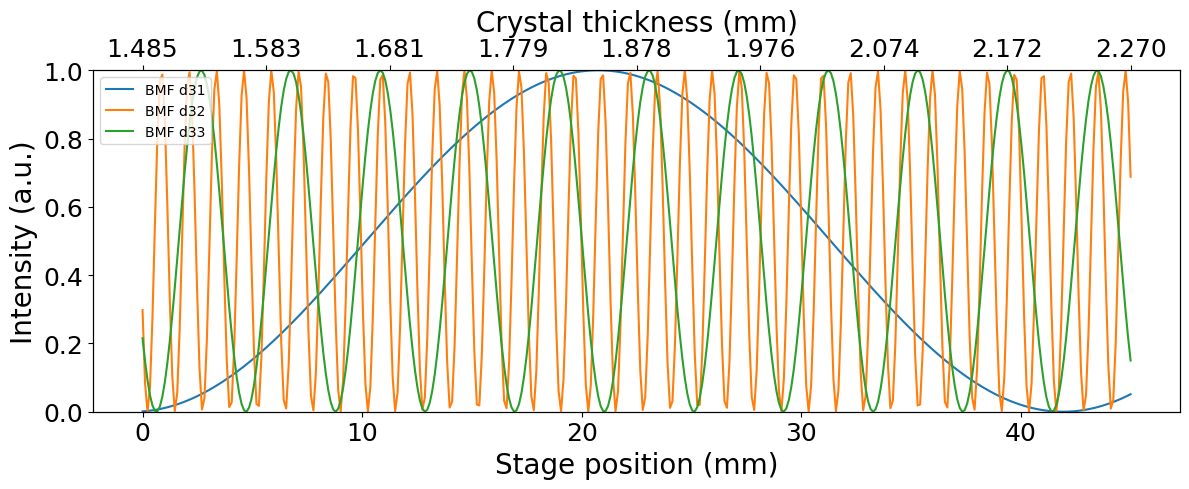

In [10]:
# plt.rcParams['font.size'] = 10

ft_labels = 20
ft_ticks = 18
fig, ax = plt.subplots(figsize=(12, 5))
for dij, strategy in strategies.items():
    fringe, aux = strategy._maker_fringes(
        override={"L":1.8 ,"wedge_deg": 1.0},
        return_aux=True
        )
    thickness = aux["L_array"]
    ax.plot(x, fringe, label=f'BMF {dij}')

# ---- Bottom x-axis (stage position) ----
ax.set_xlabel('Stage position (mm)', fontsize=ft_labels)
ax.set_ylabel('Intensity (a.u.)', fontsize=ft_labels)
ax.tick_params(axis="x", labelsize=ft_ticks)
ax.tick_params(axis="y", labelsize=ft_ticks)
ax.set_ylim(0, 1)

# ---- Top x-axis (crystal thickness) ----
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

# Choose tick positions from stage axis
n_ticks = 9
x_ticks = np.linspace(x.min(), x.max(), n_ticks)

# Interpolate thickness at those positions
thickness_ticks = np.interp(x_ticks, x, thickness)

ax_top.set_xticks(x_ticks)
ax_top.tick_params(axis="x", labelsize=ft_ticks)
ax_top.set_xticklabels([f"{t:.3f}" for t in thickness_ticks])
ax_top.set_xlabel("Crystal thickness (mm)", fontsize=ft_labels)


fig.tight_layout()
ax.legend(loc='upper left')
plt.show()